In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import glob
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/utils/')
sys.path.append('../../../src/benchmark/')
from build_model import resnet50_
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from prediction_analysis import confusion_matrix, plot_cm, show_cm

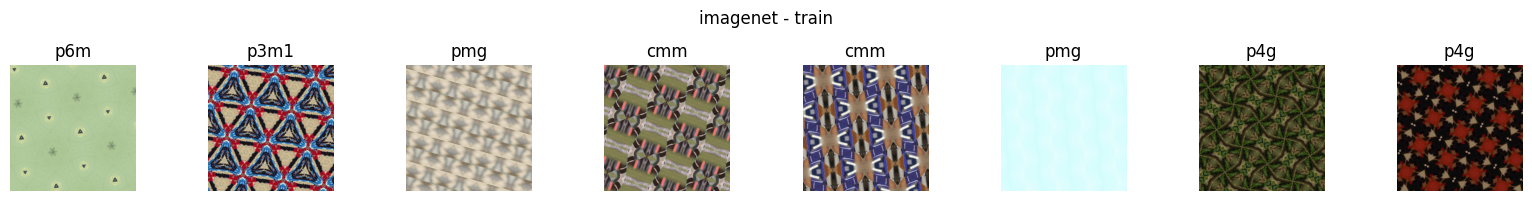

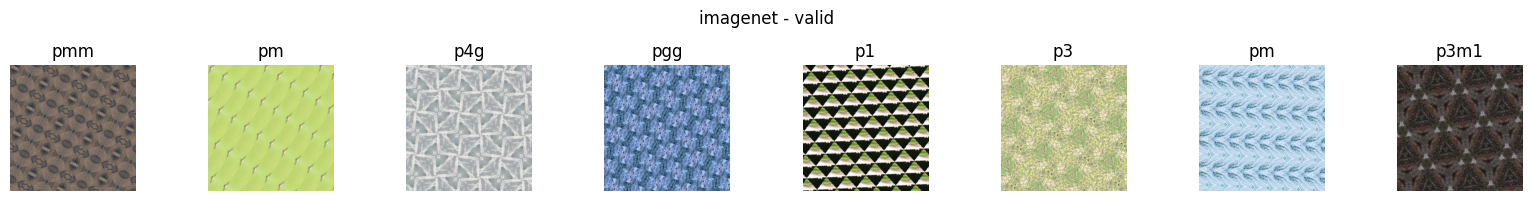

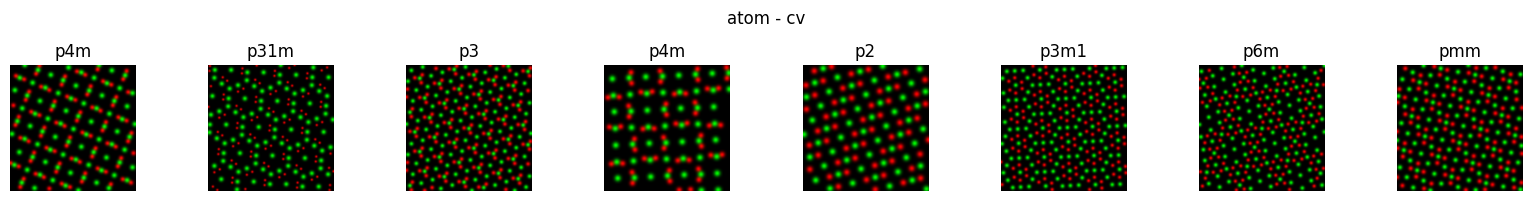

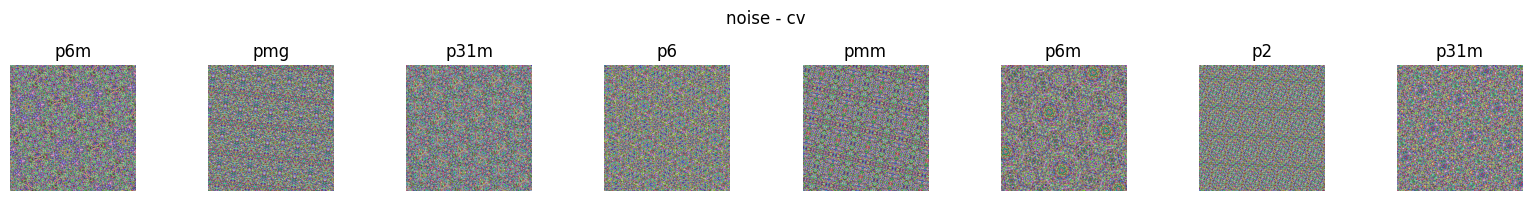

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
cv_atom_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
cv_atom_dl = DataLoader(cv_atom_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(cv_atom_dl, label_converter=label_converter, title='atom - cv')

# atom
cv_noise_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
cv_noise_dl = DataLoader(cv_noise_ds, batch_size=600, shuffle=False, num_workers=6)
viz_dataloader(cv_noise_dl, label_converter=label_converter, title='noise - cv')

In [4]:
model = resnet50_(in_channels=3, n_classes=17)

model = torch.load('../../../saved_models/Train_ImageNet-CrossValidate_Atom/epoch-50.pt')
device = torch.device('cuda:2')

NAME = 'Train_ImageNet-CrossValidate_Atom'

### generate confusion matrix

In [20]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-train_imagenet_cm.npy', cm)

cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-valid_imagenet_cm.npy', cm)

cm = confusion_matrix(model, cv_atom_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-cv_atom_cm.npy', cm)

cm = confusion_matrix(model, cv_noise_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-cv_noise_cm.npy', cm)

100%|██████████| 134/134 [00:46<00:00,  2.89it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4738.0,4752.0,4717.0,4721.0,4686.0,4767.0,4698.0,4611.0,4717.0,4723.0,4582.0,4734.0,4719.0,4655.0,4771.0,4622.0,4787.0


Accuracy for these batches: 99.995%


100%|██████████| 34/34 [00:12<00:00,  2.66it/s]

...

Accuracy for these batches: 35.17%


100%|██████████| 170/170 [01:03<00:00,  2.68it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 35.17745098039215%


In [8]:
cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-train_imagenet_cm.npy', cm)

cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-valid_imagenet_cm.npy', cm)

cm = confusion_matrix(model, cv_atom_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-cv_atom_cm.npy', cm)

cm = confusion_matrix(model, cv_noise_dl, symmetry_classes, device, n_batches='all')
np.save(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}-cv_noise_cm.npy', cm)

  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:48<00:00,  2.75it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,4738.0,4752.0,4717.0,4721.0,4686.0,4767.0,4698.0,4611.0,4717.0,4723.0,4582.0,4734.0,4719.0,4655.0,4771.0,4622.0,4787.0


Accuracy for these batches: 99.995%


...

Accuracy for these batches: 35.17%


100%|██████████| 170/170 [01:05<00:00,  2.61it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0


Accuracy for these batches: 35.17745098039215%


### visualize confusions 

printing set for seaborn


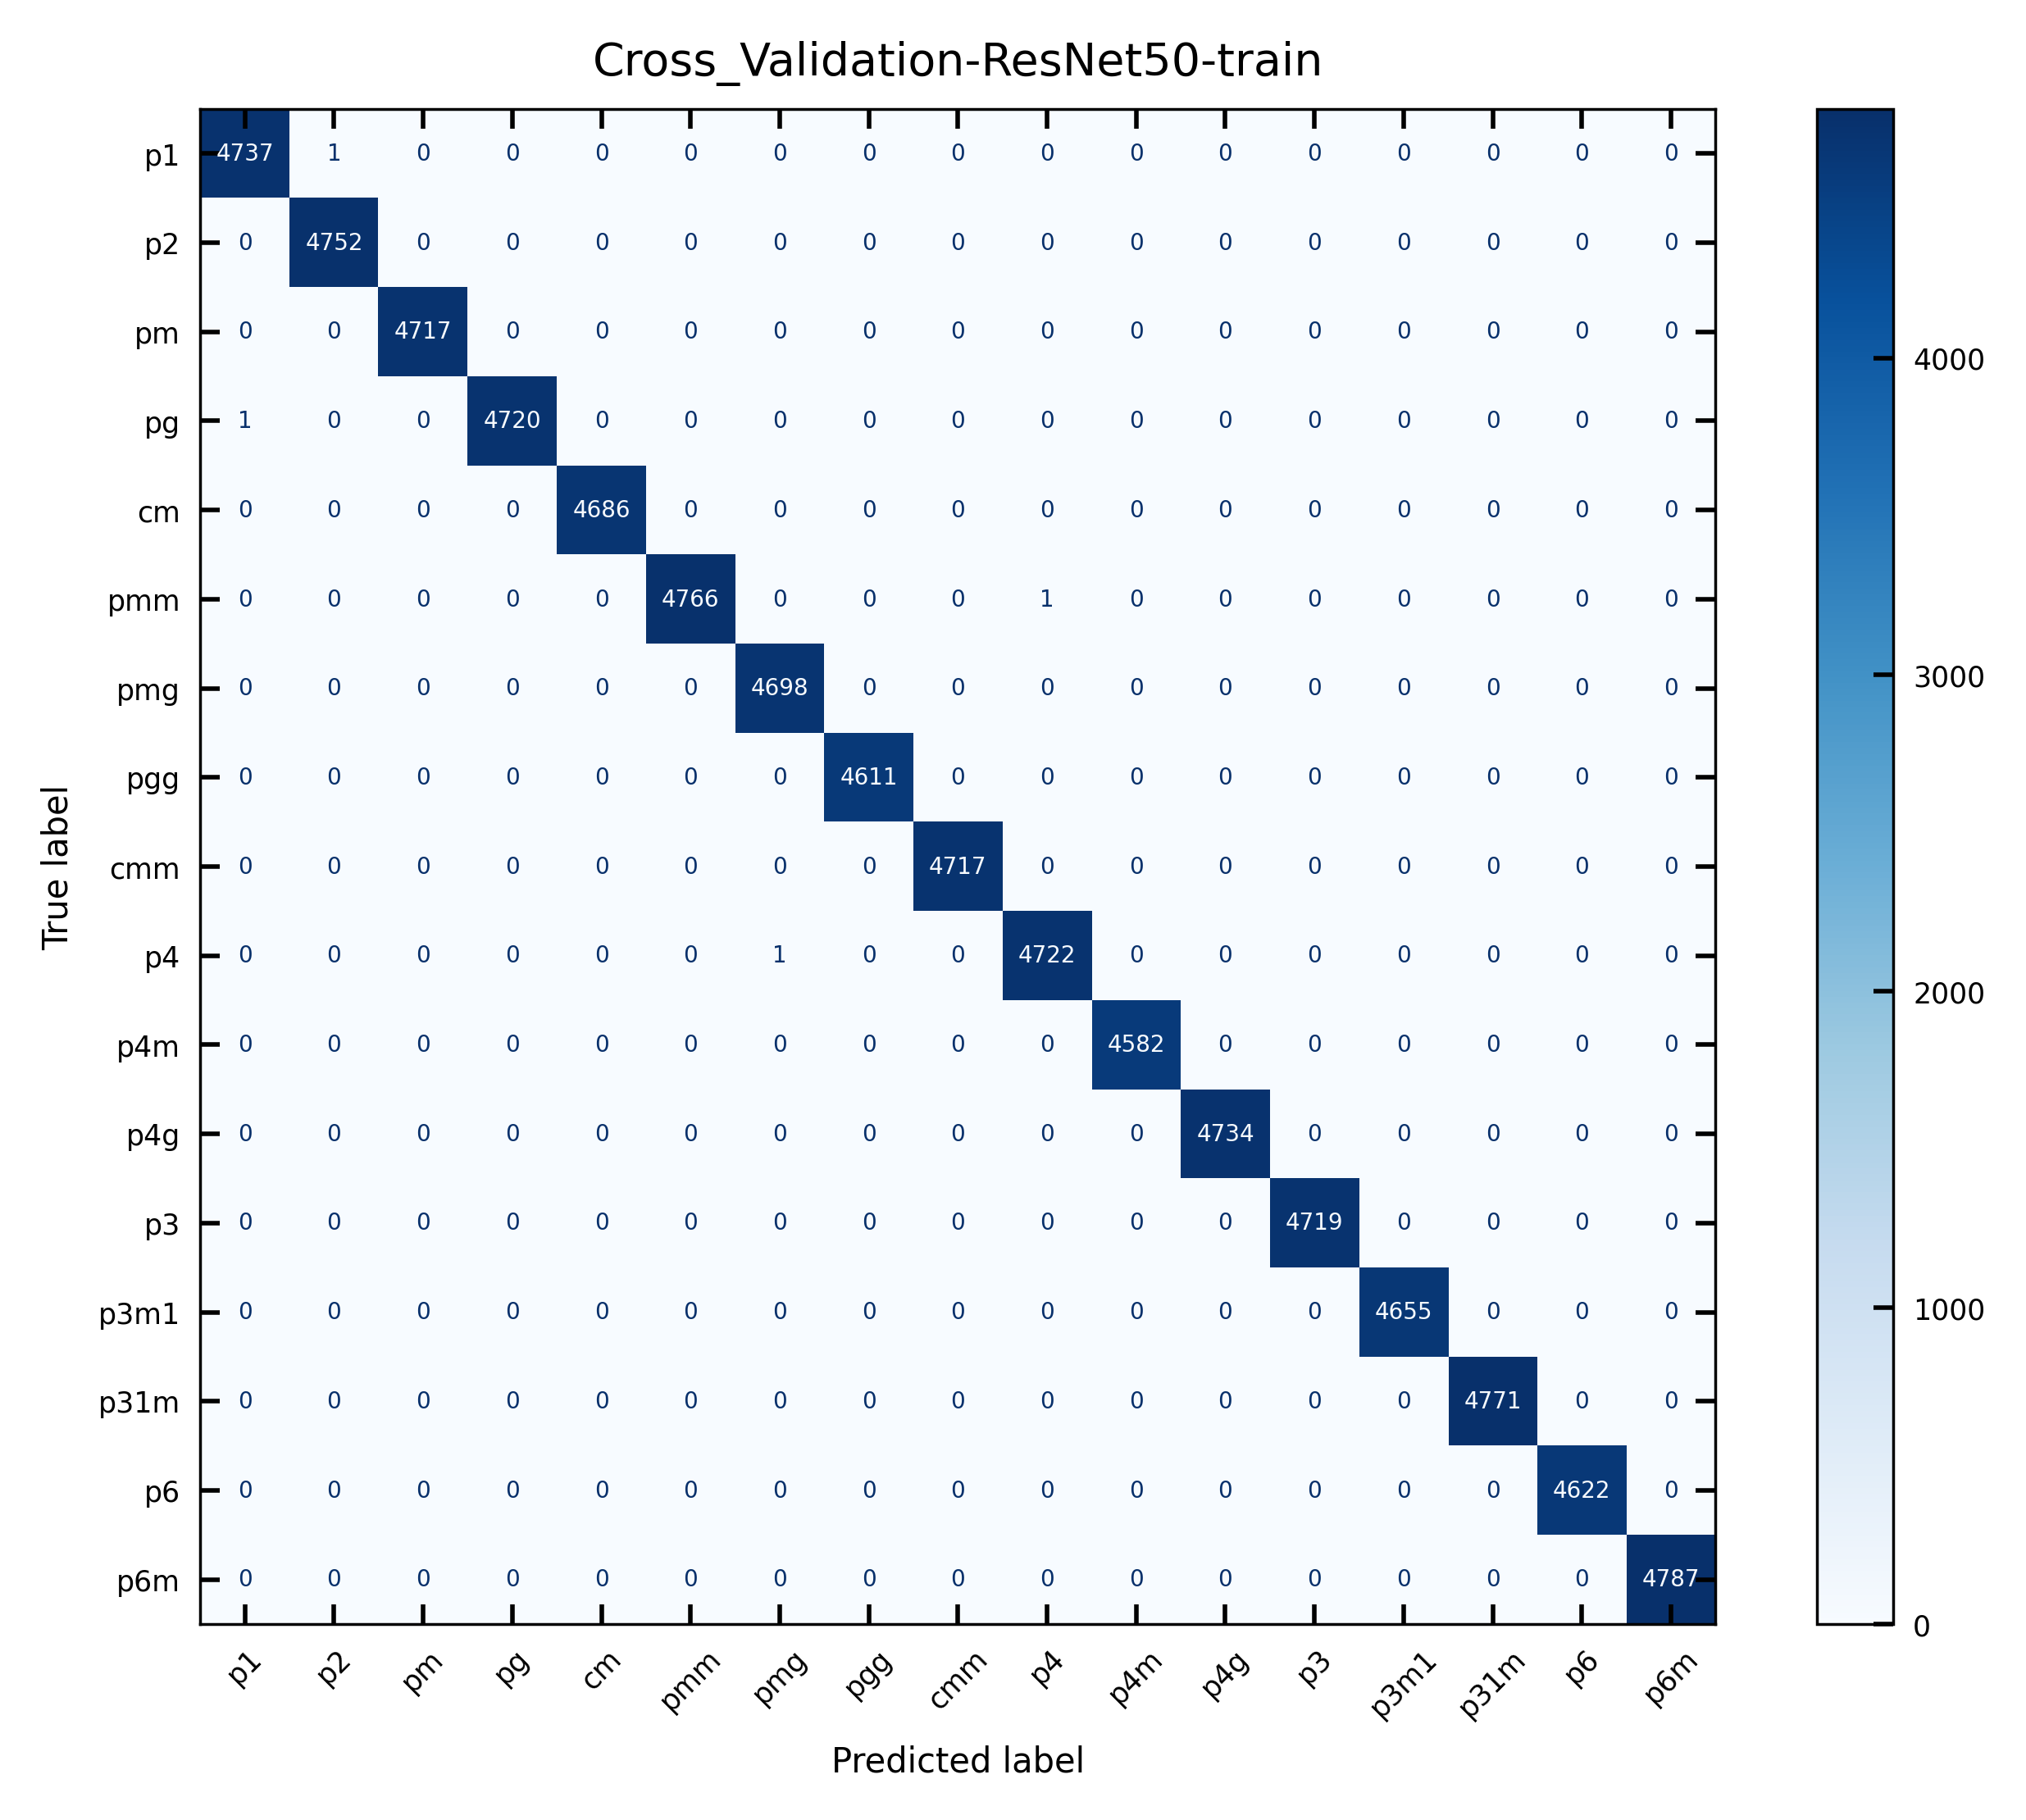

printing set for seaborn


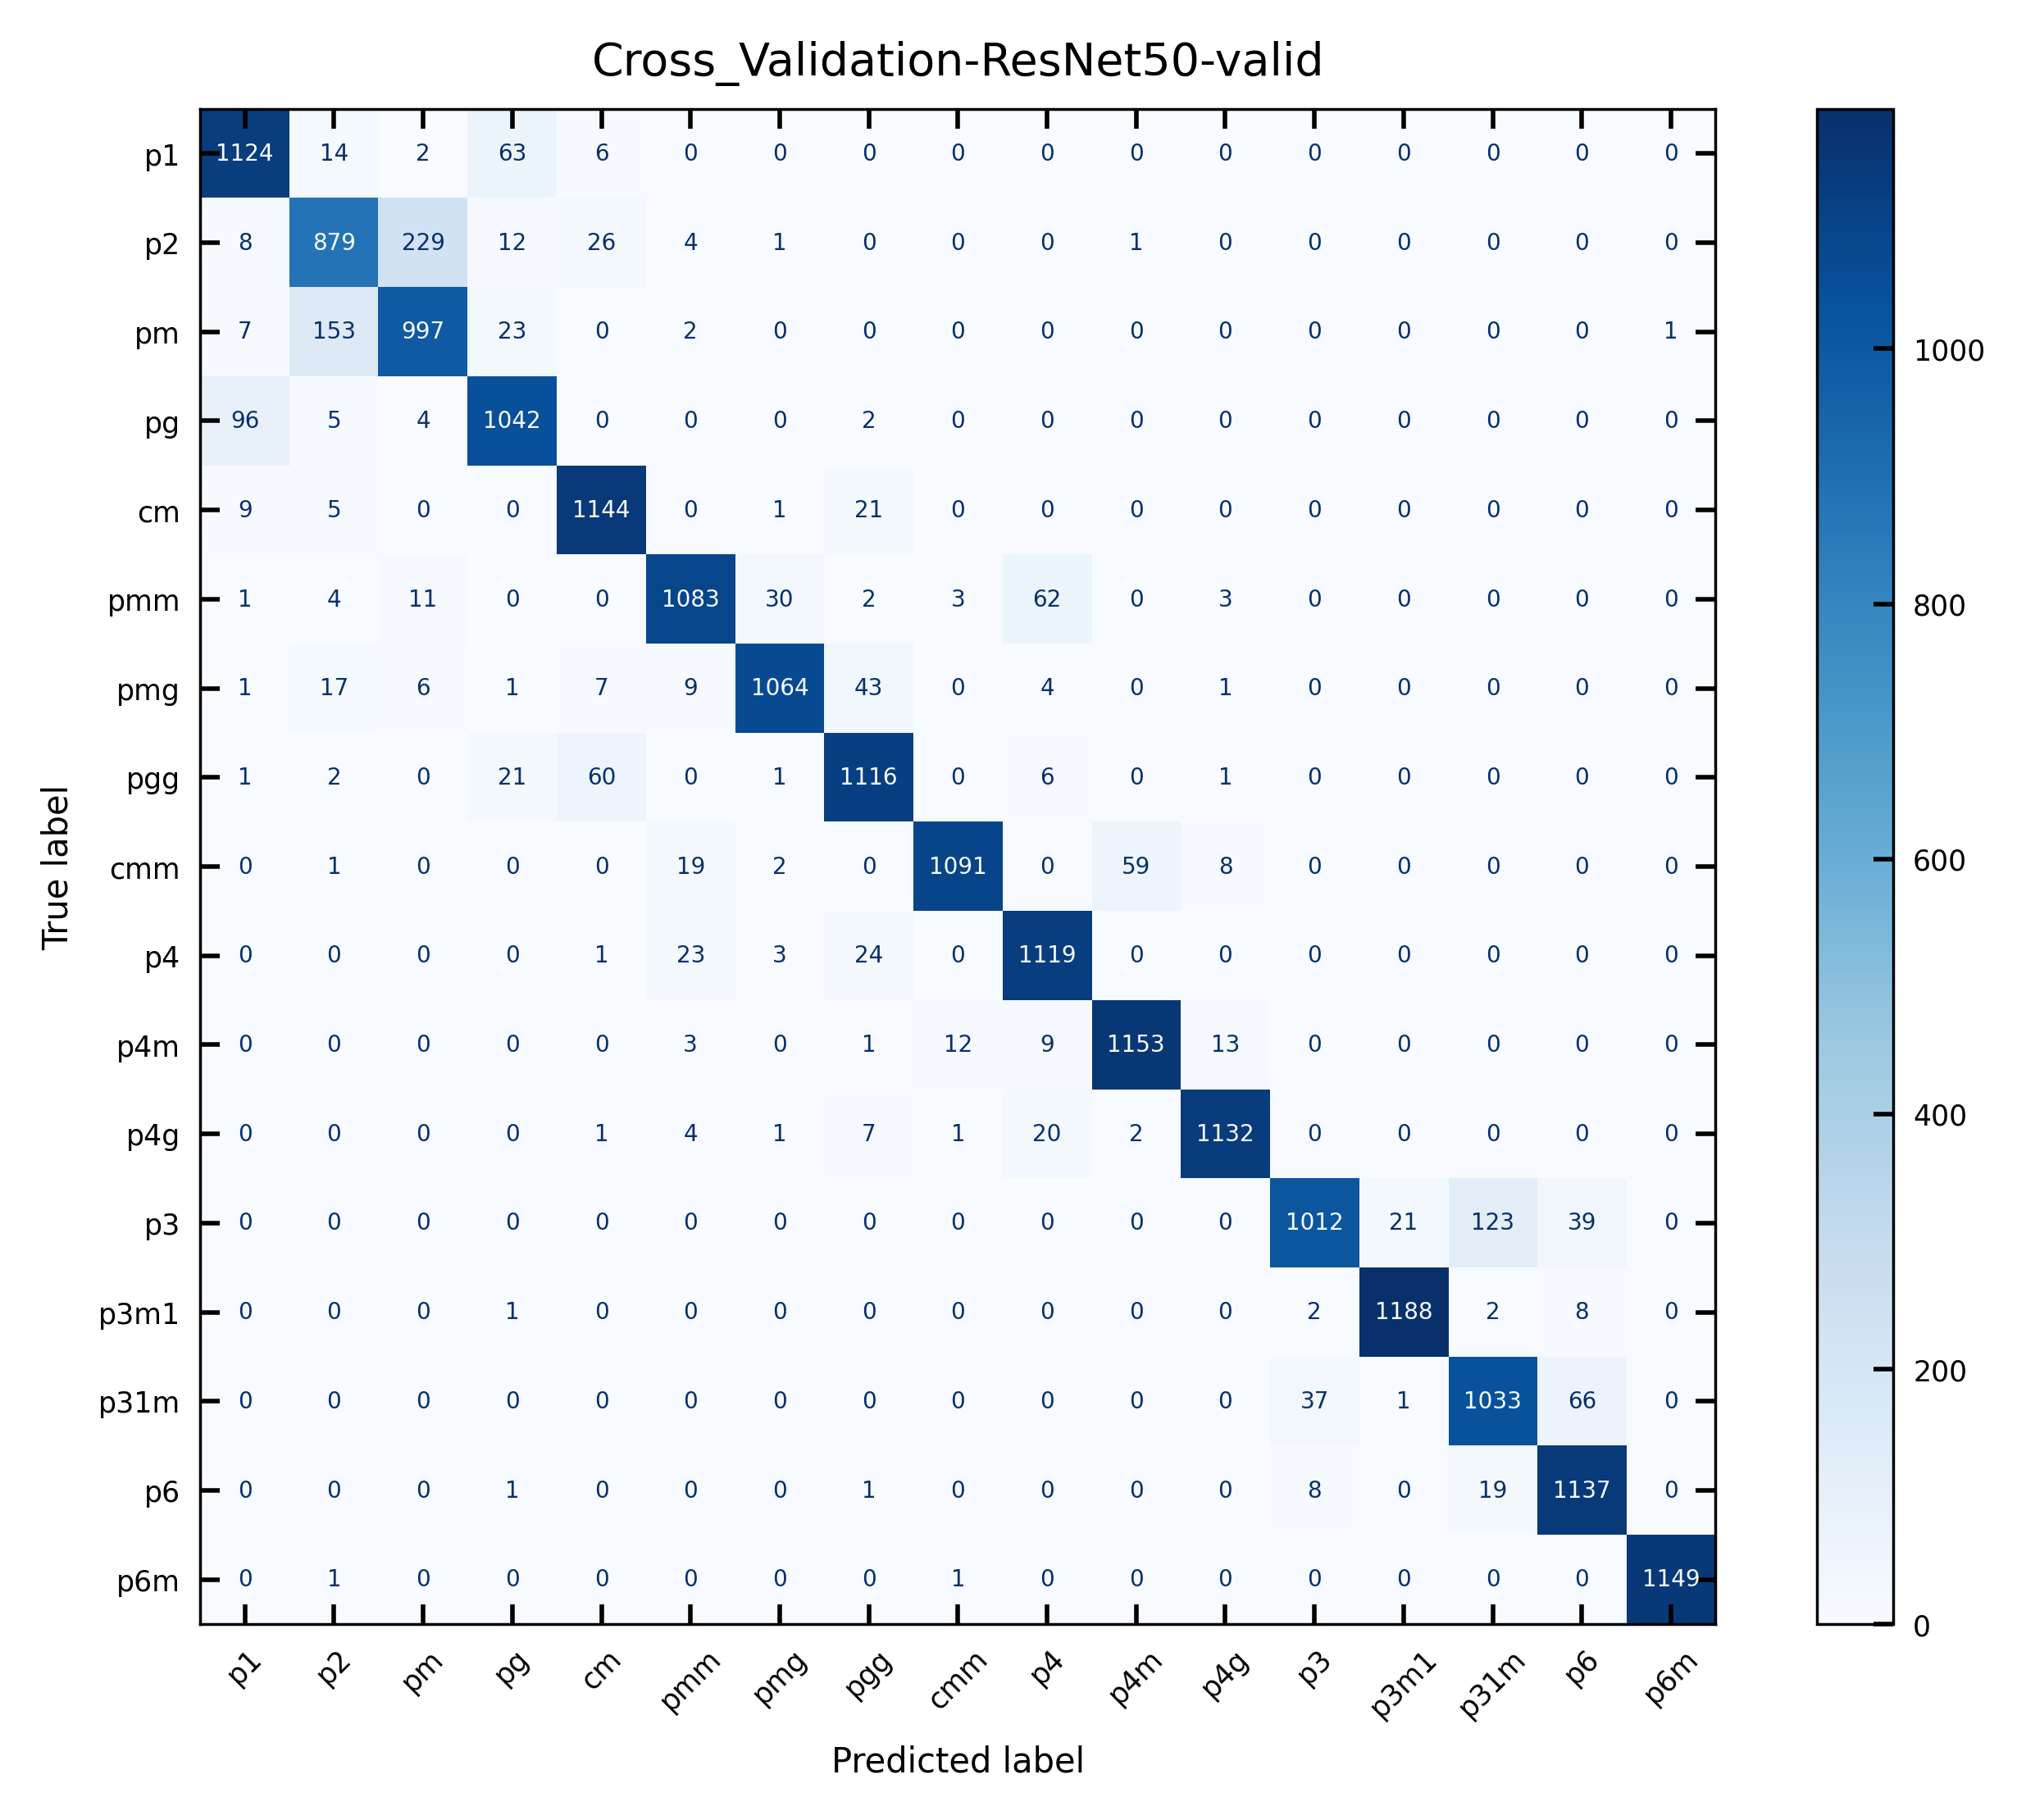

printing set for seaborn


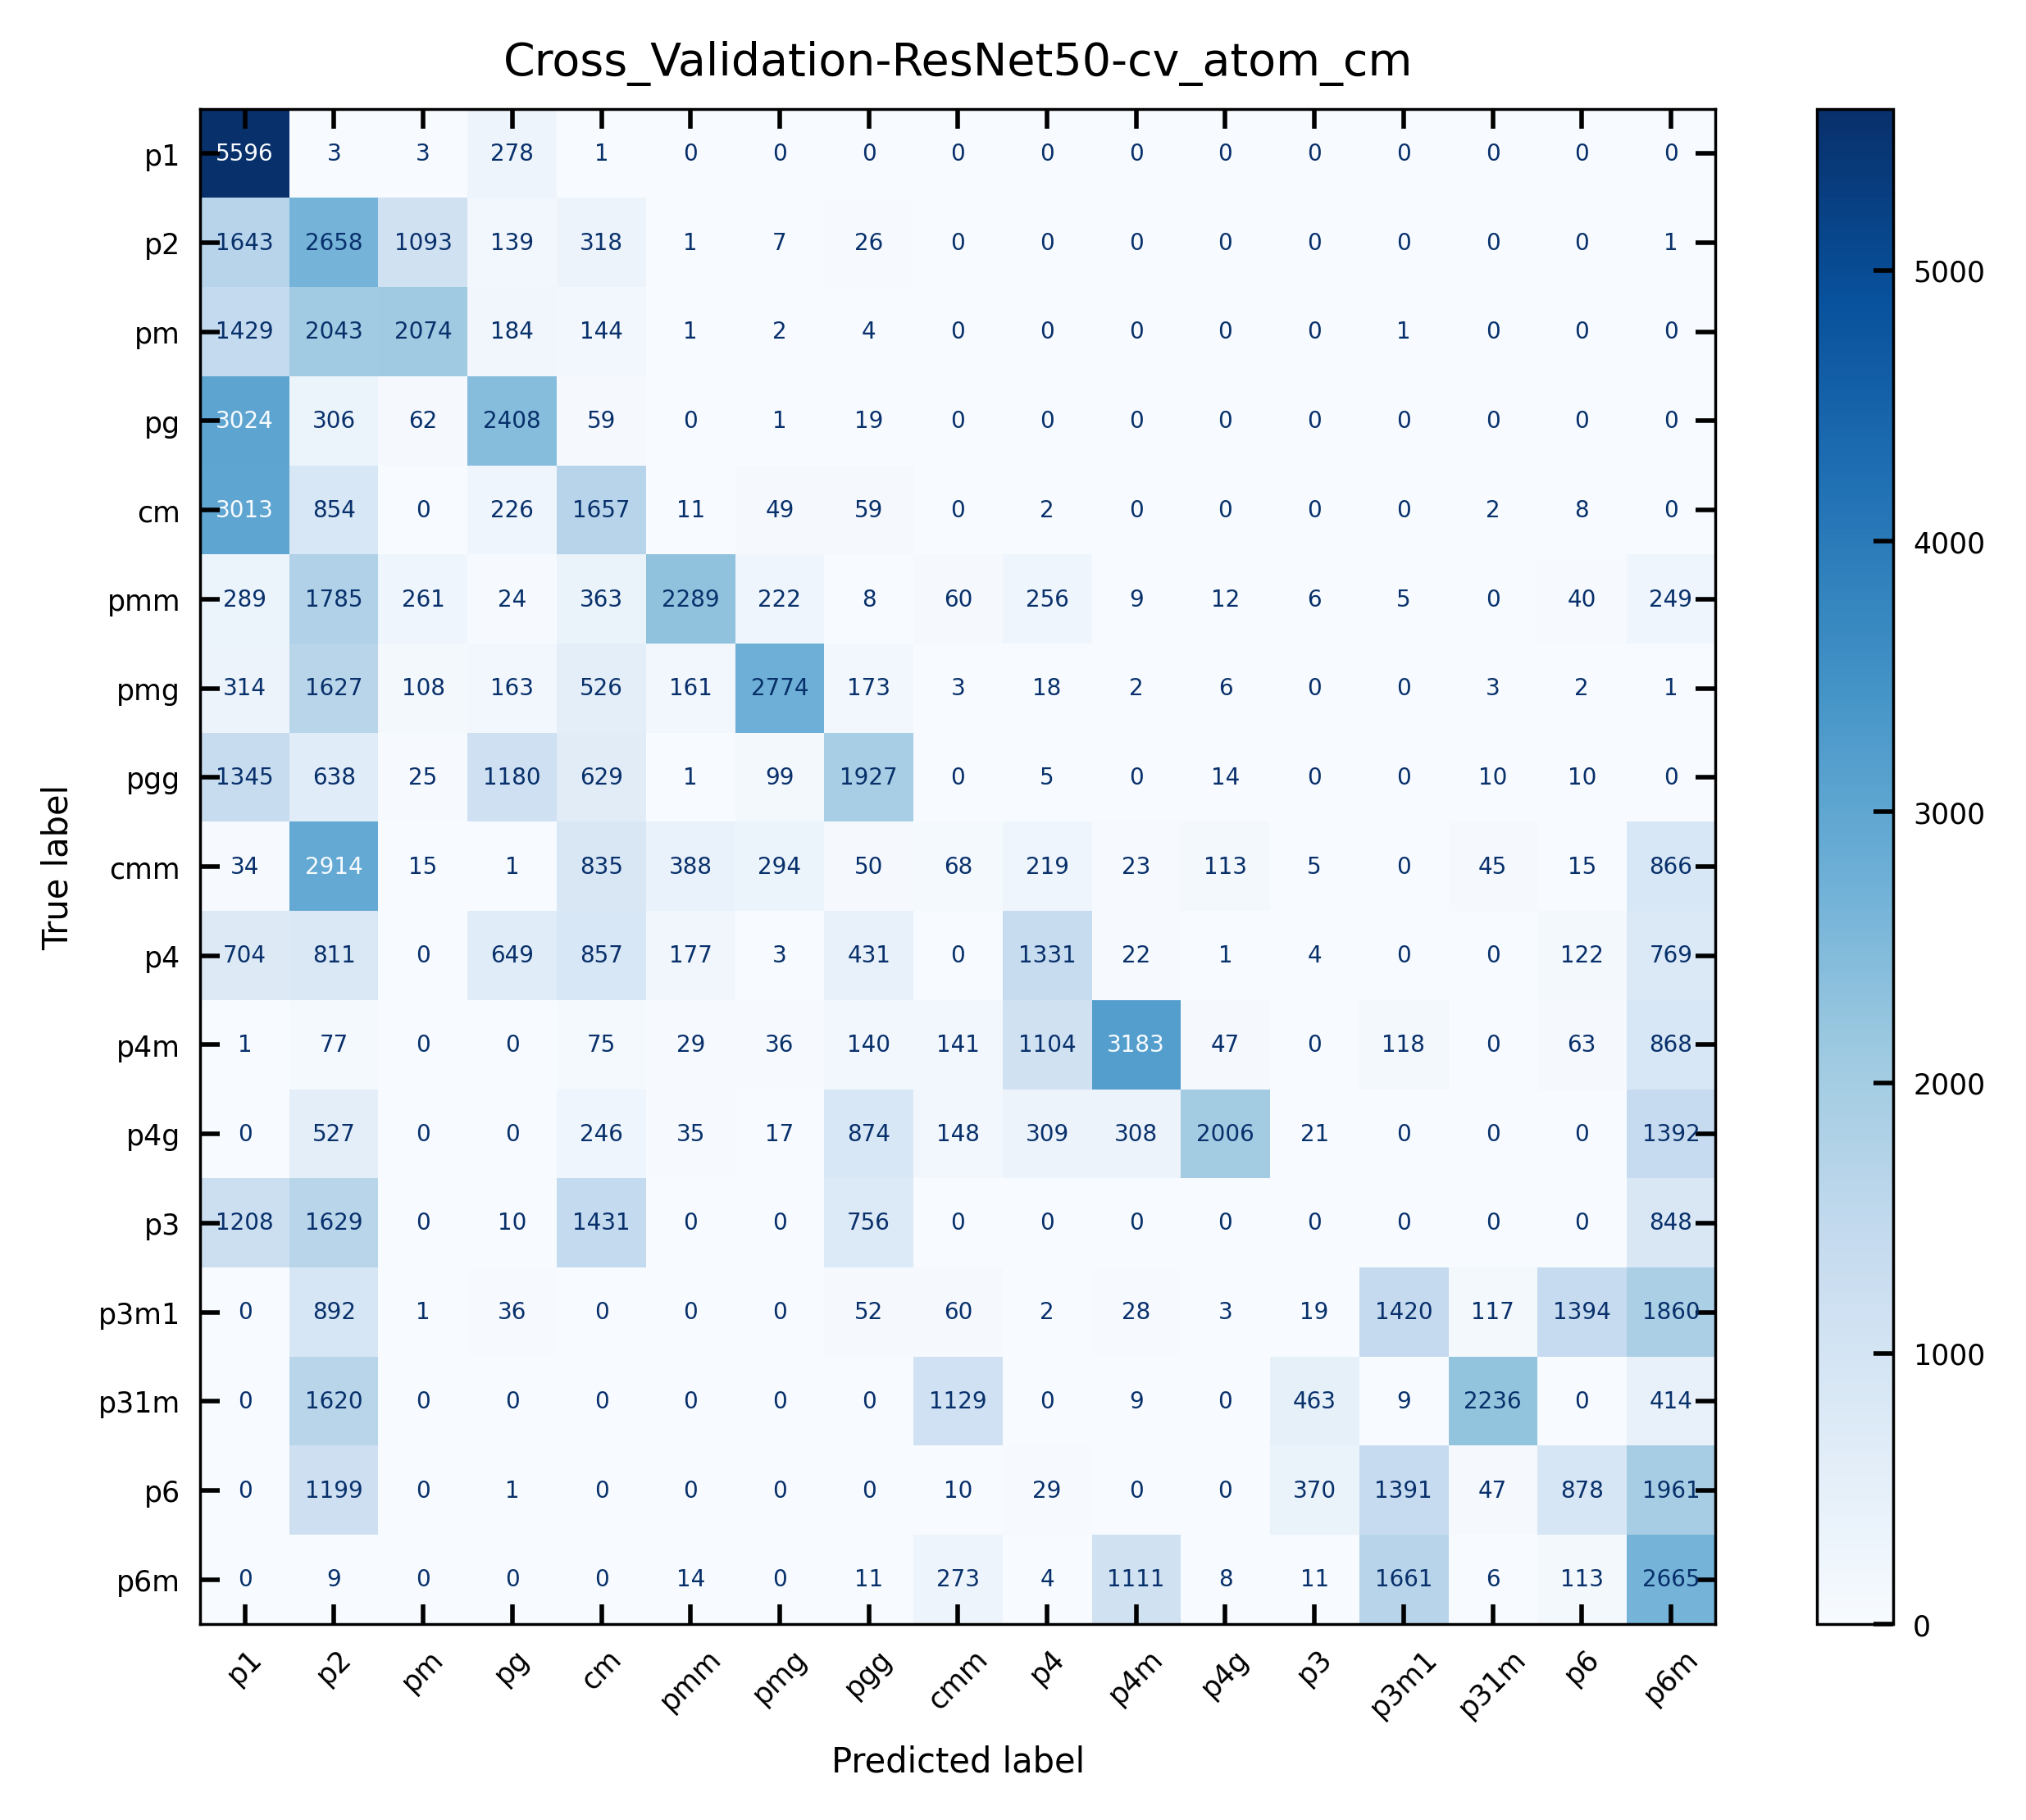

printing set for seaborn


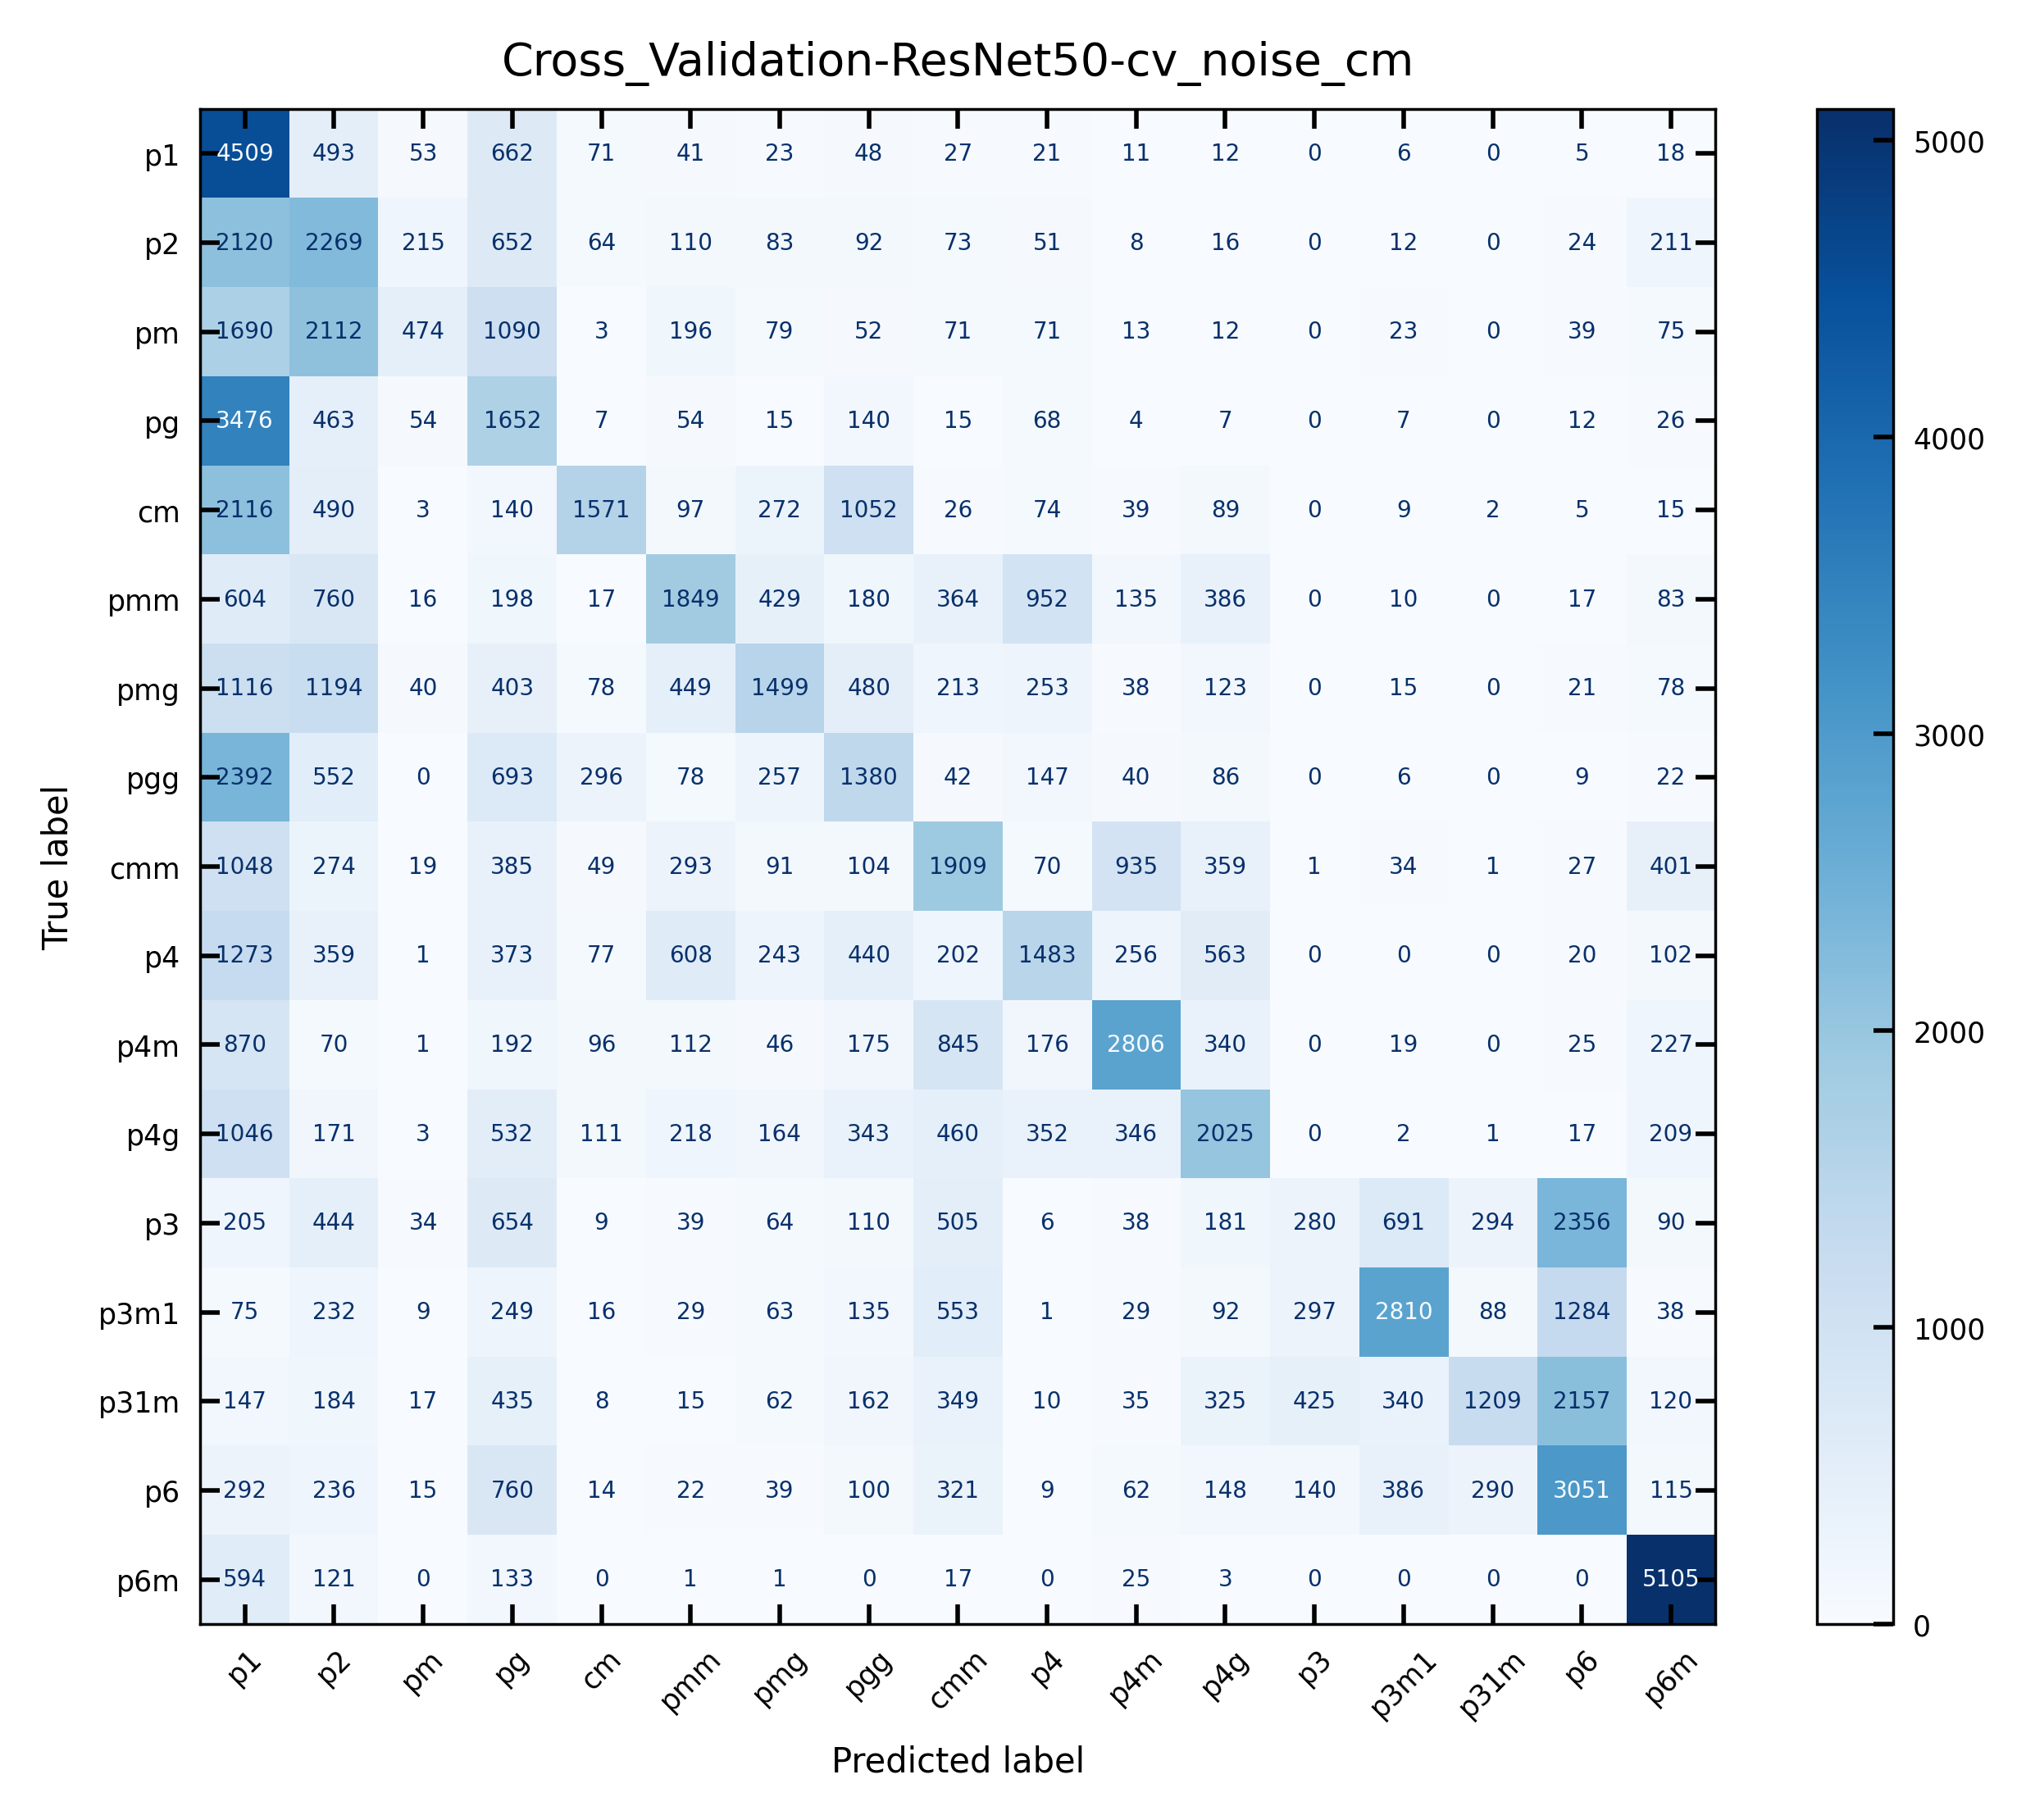

In [6]:
files = glob.glob(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}*')
keywords = ['train', 'valid', 'cv_atom_cm', 'cv_noise_cm']
show_cm(files, keywords, title_head='Cross_Validation-ResNet50-',
        file_path=f'../../../figures/Benchmark/Cross_Validation-ResNet50/',
        cm_style='simple', fig_style='printing', font_size=4)

### visualize confusions in compact layout

In [18]:
files

['../../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-cv_atom_cm.npy',
 '../../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-train_imagenet_cm.npy',
 '../../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-valid_imagenet_cm.npy',
 '../../../saved_results/Benchmark/Cross_Validation-ResNet50/Train_ImageNet-CrossValidate_Atom-cv_noise_cm.npy']

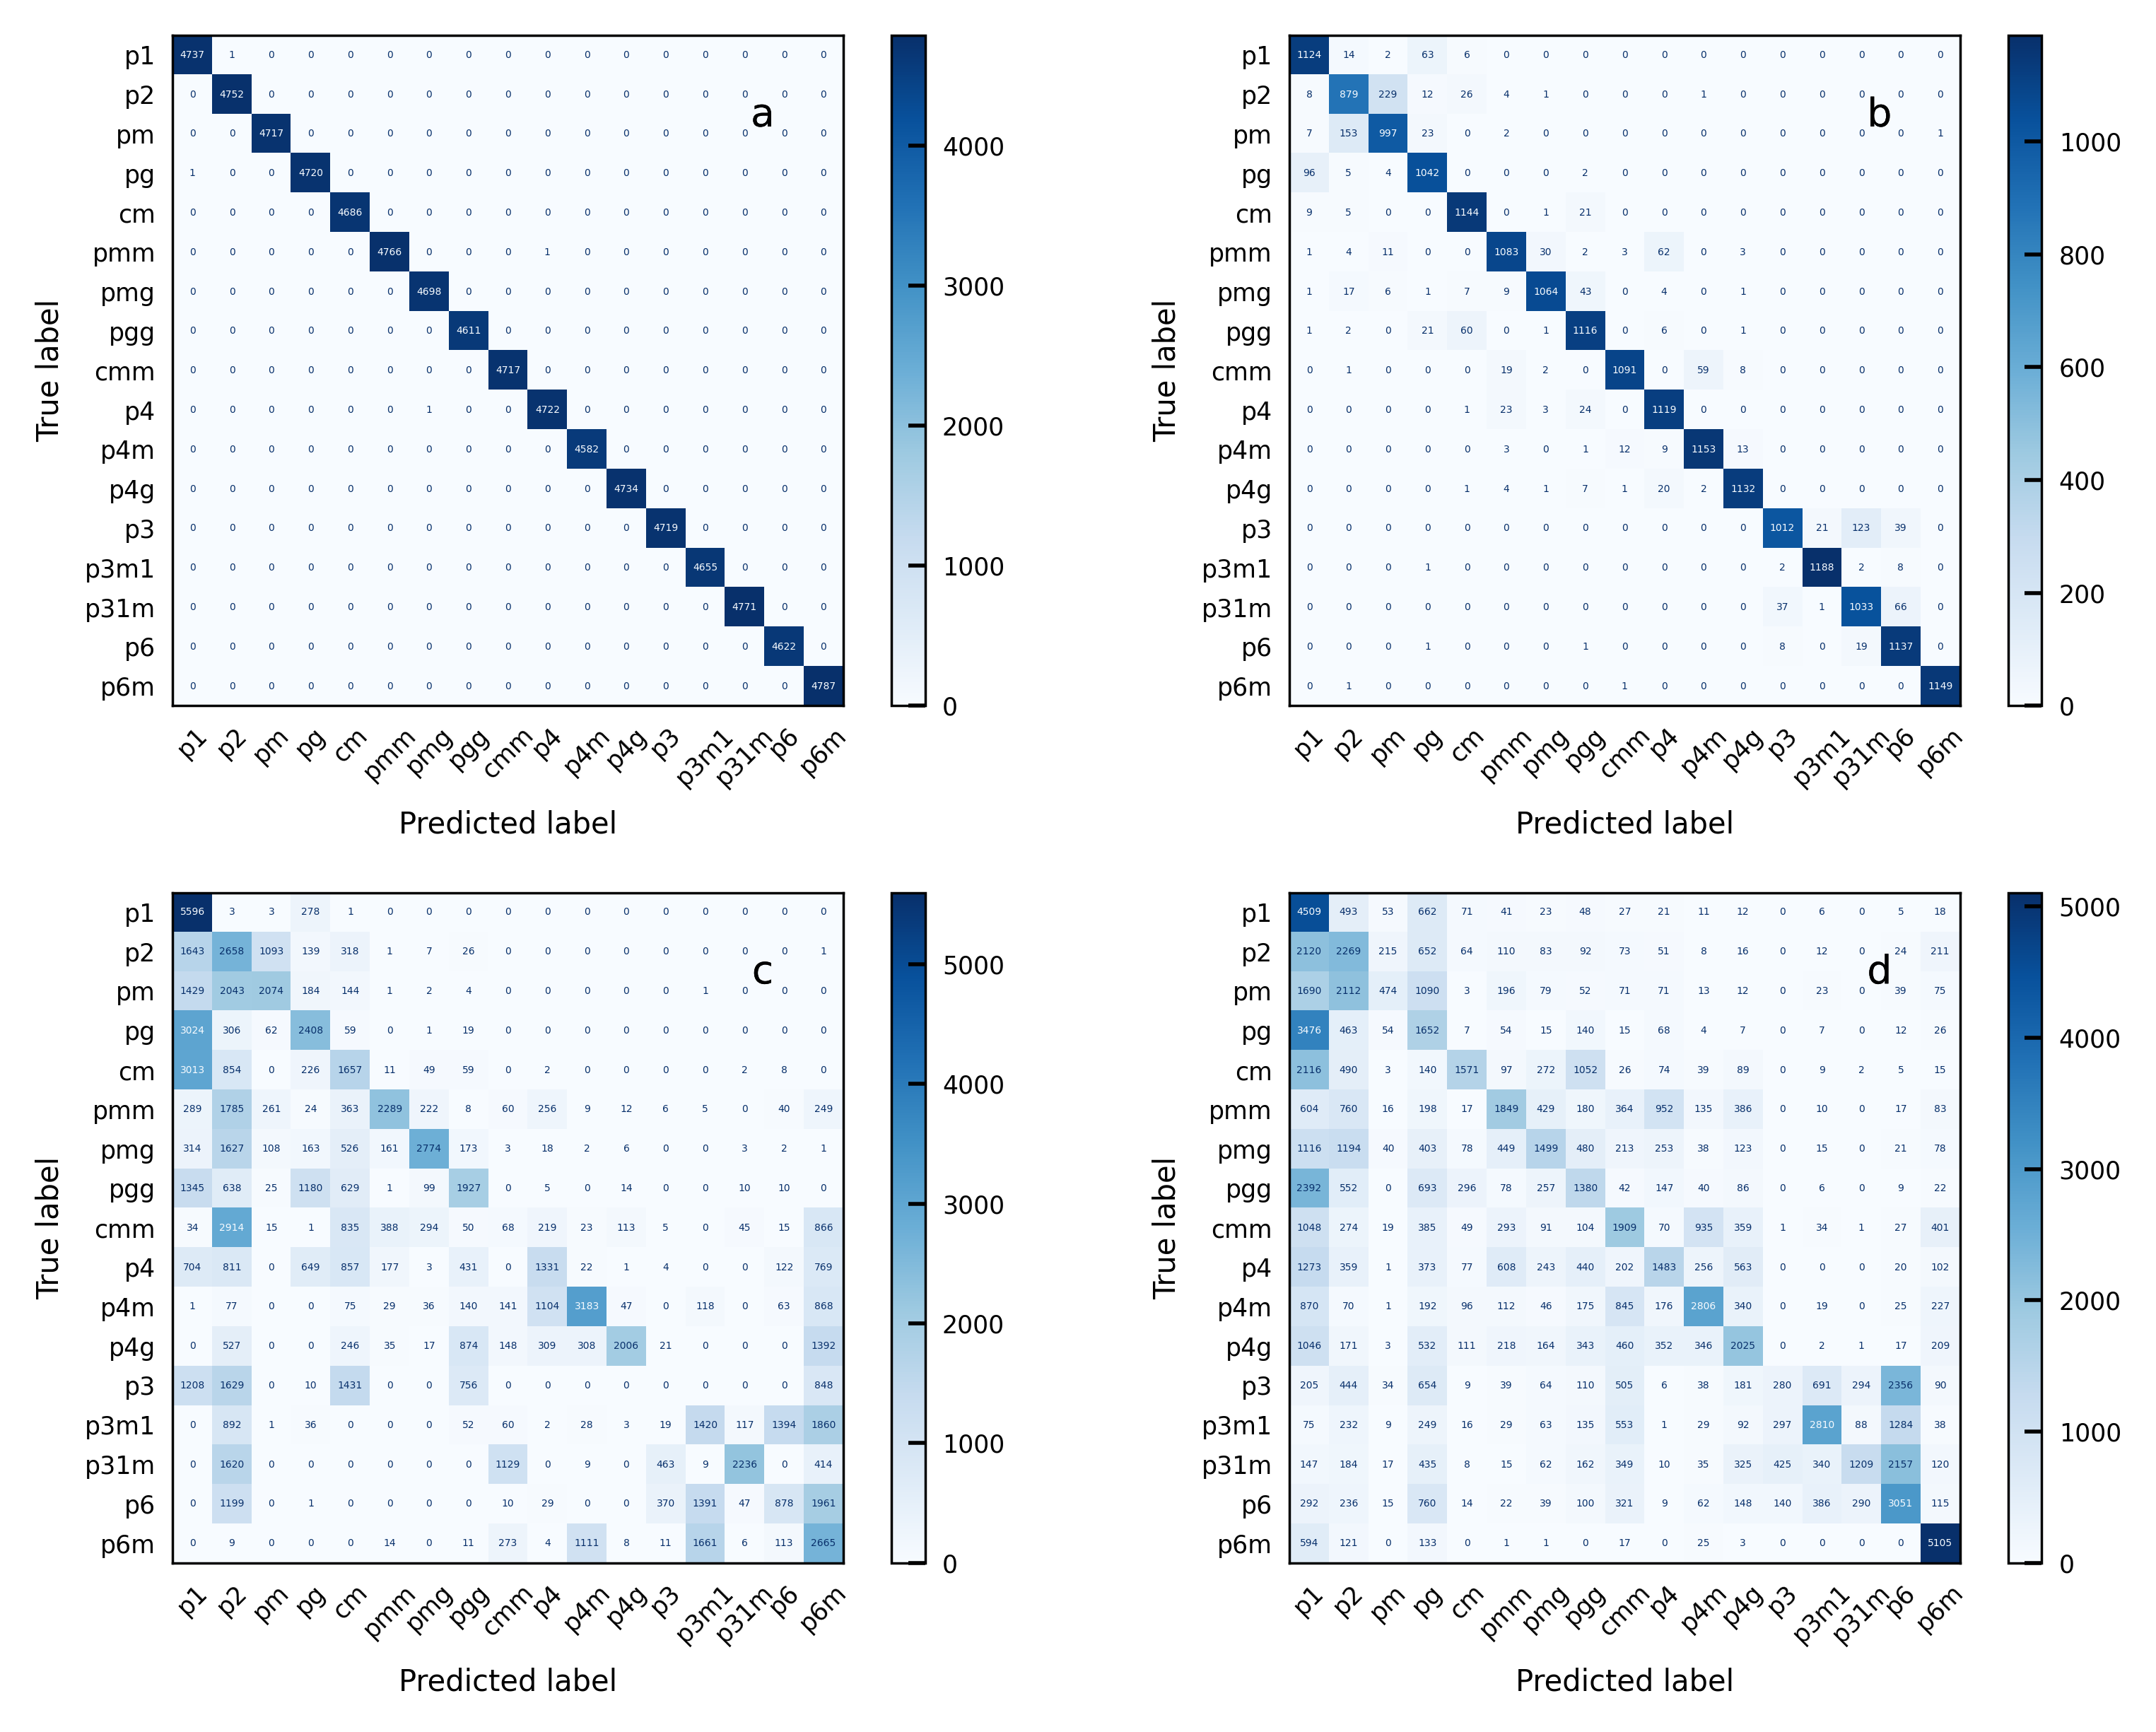

In [7]:
files = glob.glob(f'../../../saved_results/Benchmark/Cross_Validation-ResNet50/{NAME}*')
keywords = ['train', 'valid', 'cv_atom_cm', 'cv_noise_cm']

show_cm(files, keywords, summary=True, title_head=None, cm_style='simple', fig_style='printing', font_size=2,
        file_path='../../../figures/Benchmark/Cross_Validation-ResNet50/Summary_cm-Cross_Validation-ResNet50')